# GANs and Autoencoders / VAEs

## 📚 Learning Objectives

By completing this notebook (~20 min), you will:
- Build a simple **autoencoder** (encoder → latent → decoder) and reconstruct images (e.g. MNIST)
- Understand the idea of **GAN** (generator vs discriminator) and **VAE** (probabilistic latent)
- See why we use a GAN (instead of a single generator) and why we use autoencoders for compression/denoising

---

## 🌍 Real life

**Where is this used?** Autoencoders are used for **denoising**, **compression**, and **anomaly detection**. GANs are used for **image generation**, **style transfer**, and **data augmentation**. VAEs are used for **generative models** and **latent representation**.

**In this notebook we use** an **autoencoder** to **reconstruct** MNIST digits (encoder compresses, decoder reconstructs). We use an **autoencoder** (instead of a plain NN) **because** it learns a **latent representation**; we use **GANs** (generator + discriminator) **instead of** a single generator **because** the discriminator gives a **training signal** (real vs fake) so the generator improves.

**📌 Covers slide(s):** **04** (AutoEncoders), **09** (GANs). *Do this notebook after those slides.*

---

**Before starting:** Run the imports cell below.

## Theory (short)

- **Autoencoder:** Encoder maps input → **latent** (smaller); decoder maps latent → **reconstruction**. Loss = reconstruction error (e.g. MSE). Used for compression, denoising, anomaly detection.
- **GAN:** **Generator** produces fake samples; **Discriminator** tries to tell real vs fake. They train against each other. We use GAN (instead of only a generator) because the discriminator provides a learning signal for "what looks real."
- **VAE:** Variational autoencoder; latent is **probabilistic** (mean + variance); we sample from the latent and decode. Balances reconstruction and regularized latent.
- **We use autoencoder here** for a quick reconstruction demo; GAN/VAE would be separate notebooks for generation.

## 📥 Inputs & 📤 Outputs

**Inputs:** TensorFlow/Keras, NumPy, Matplotlib. MNIST (small subset). We build a simple autoencoder.

**Dataset:** Real — MNIST (small subset).

**Outputs:** Model summary, training loss (reconstruction), and one figure: **original vs reconstructed** images (with axis labels).

## Step 1: Imports and load MNIST

In [1]:
# Step 1: Imports and load MNIST subset for autoencoder
import numpy as np
import matplotlib.pyplot as plt

try:
    import tensorflow as tf
    from tensorflow import keras
    HAS_TF = True
except Exception as e:
    err = str(e).lower()
    if "charset_normalizer" in err or "md__mypyc" in err or "partially initialized" in err:
        print("⚠️ Fix: pip install --upgrade charset-normalizer requests, then restart kernel.")
        raise RuntimeError("Fix: pip install --upgrade charset-normalizer requests, then restart kernel.") from e
    HAS_TF = False

if HAS_TF:
    (x_train, _), (x_test, _) = keras.datasets.mnist.load_data()
    x_train = x_train.astype(np.float32) / 255.0
    x_test = x_test.astype(np.float32) / 255.0
    x_train = x_train.reshape(-1, 784)
    x_test = x_test.reshape(-1, 784)
    x_train, x_test = x_train[:5000], x_test[:1000]
    print("Train:", x_train.shape, "Test:", x_test.shape)
else:
    print("Install TensorFlow: pip install tensorflow")

Train: (5000, 784) Test: (1000, 784)


## Step 2: Build autoencoder (we use encoder + decoder instead of a single layer to learn a compressed latent)

In [2]:
if HAS_TF:
    latent_dim = 32
    encoder = keras.Sequential([
        keras.layers.Dense(128, activation="relu", input_shape=(784,)),
        keras.layers.Dense(latent_dim, activation="relu"),
    ])
    decoder = keras.Sequential([
        keras.layers.Dense(128, activation="relu", input_shape=(latent_dim,)),
        keras.layers.Dense(784, activation="sigmoid"),
    ])
    inp = keras.Input(shape=(784,))
    latent = encoder(inp)
    out = decoder(latent)
    autoencoder = keras.Model(inp, out)
    autoencoder.compile(optimizer="adam", loss="mse")
    autoencoder.summary()

Model: "model"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


 input_1 (InputLayer)        [(None, 784)]             0         


 sequential (Sequential)     (None, 32)                104608    


 sequential_1 (Sequential)   (None, 784)               105360    


Total params: 209968 (820.19 KB)


Trainable params: 209968 (820.19 KB)


Non-trainable params: 0 (0.00 Byte)


_________________________________________________________________


## Step 3: Train (2 epochs) and plot original vs reconstructed

Epoch 1/2



 1/40 [..............................] - ETA: 3s - loss: 0.2317


40/40 [==============================] - 0s 2ms/step - loss: 0.1202 - val_loss: 0.0687


Epoch 2/2



 1/40 [..............................] - ETA: 0s - loss: 0.0720


40/40 [==============================] - 0s 1ms/step - loss: 0.0645 - val_loss: 0.0563


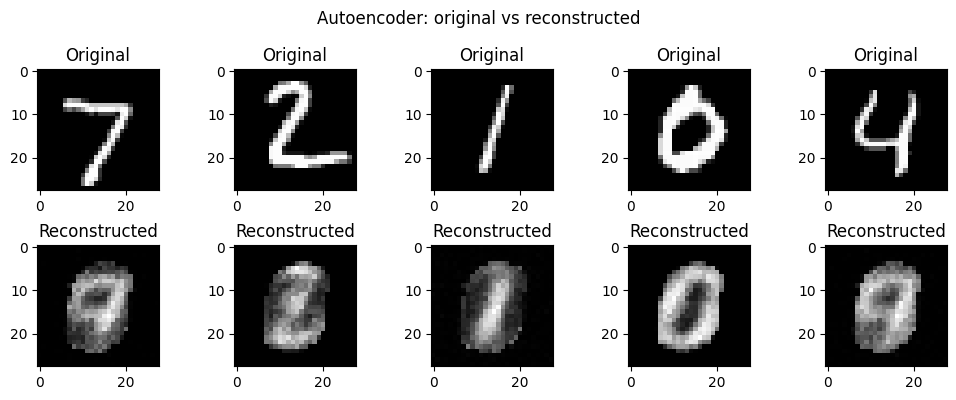

Reconstruction loss (last): 0.0563


In [3]:
if HAS_TF:
    history = autoencoder.fit(x_train, x_train, validation_data=(x_test, x_test), epochs=2, batch_size=128, verbose=1)
    recons = autoencoder.predict(x_test[:5], verbose=0)
    fig, axs = plt.subplots(2, 5, figsize=(10, 4))
    for i in range(5):
        axs[0, i].imshow(x_test[i].reshape(28, 28), cmap="gray")
        axs[0, i].set_title("Original")
        axs[0, i].set_xlabel("")
        axs[0, i].set_ylabel("")
        axs[1, i].imshow(recons[i].reshape(28, 28), cmap="gray")
        axs[1, i].set_title("Reconstructed")
        axs[1, i].set_xlabel("")
        axs[1, i].set_ylabel("")
    plt.suptitle("Autoencoder: original vs reconstructed")
    plt.tight_layout()
    plt.show()
    print("Reconstruction loss (last): %.4f" % history.history["val_loss"][-1])

## 🧩 Mini-exercise

**Try it (choose one):** Reduce the latent dimension (e.g. 16 → 8) and retrain. How does reconstruction quality change? Or add one more Dense layer in the encoder and decoder and compare.

---

## ✅ Summary

**What you did:** Built an autoencoder (encoder → latent → decoder), trained it to reconstruct MNIST, and plotted original vs reconstructed.

**In real life you'd also:** Use convolutional autoencoders, VAEs (with KL loss), or GANs (generator + discriminator) for generation.

**The main idea:** Autoencoders learn a compressed representation (latent); GANs use a discriminator to train a generator; VAEs add a probabilistic latent.

**Next:** `02_implementing_a_vae_variational_autoencoder_for_anomaly_detection` covers VAE; `03_reinforcement_learning_fundamentals_deep_q_networks_policy_gradients` covers RL.